In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

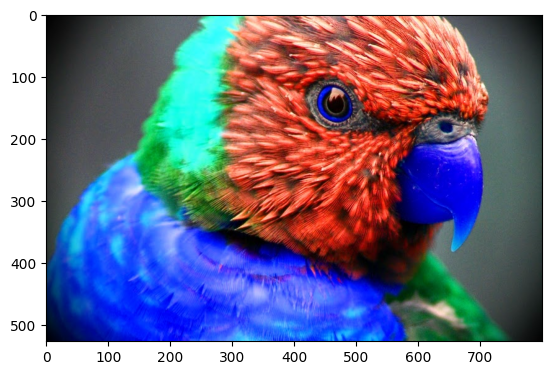

In [57]:
img = cv2.imread(r"C:\Users\ADMIN\Downloads\Bird_segmentation (1).jpg")
plt.imshow(img)

In [39]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'Original Image')

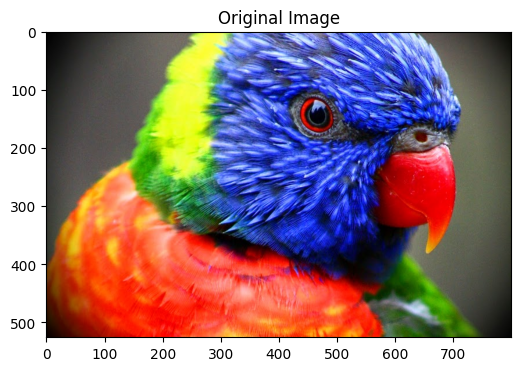

In [40]:
plt.figure(figsize=(6, 5))
plt.imshow(rgb)
plt.title("Original Image")

In [41]:
pixels = rgb.reshape((-1, 3))
pixels = np.float32(pixels)

In [42]:
K = 3
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)
_, labels, centers = cv2.kmeans(
    pixels,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

Text(0.5, 1.0, 'K-Means Segmented Image')

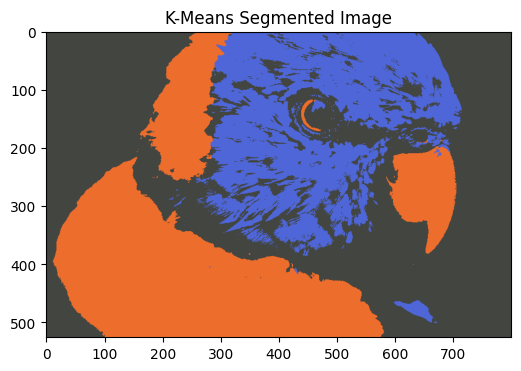

In [43]:
centers = np.uint8(centers)

# Reconstruct segmented image
segmented = centers[labels.flatten()]
segmented = segmented.reshape(rgb.shape)

plt.figure(figsize=(6, 5))
plt.imshow(segmented)
plt.title("K-Means Segmented Image")


In [44]:
# MASKING
gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)



Text(0.5, 1.0, 'Final Bird Segmentation')

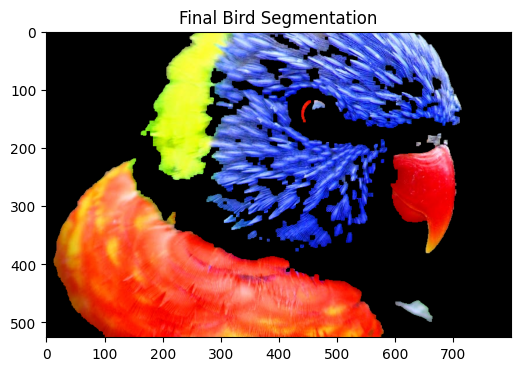

In [45]:
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
bird = cv2.bitwise_and(rgb, rgb, mask=mask)
plt.figure(figsize=(6, 5))
plt.imshow(bird)
plt.title("Final Bird Segmentation")

NOW FOR THE FRUIT SEGMENTATION

In [ ]:
img = cv2.imread(r"C:\Users\ADMIN\Downloads\fruits_segment (1).png")

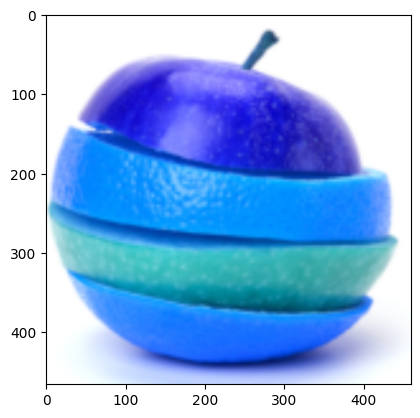

In [56]:
plt.imshow(img)

In [47]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'Original Fruits Image')

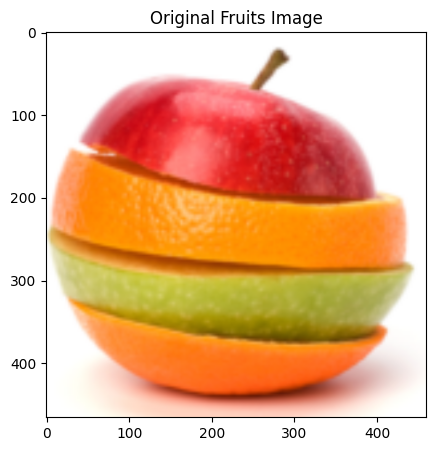

In [60]:
plt.figure(figsize=(6, 5))
plt.imshow(rgb)
plt.title("Original Fruits Image")


In [49]:
pixels = rgb.reshape((-1, 3))
pixels = np.float32(pixels)

In [50]:
K = 5
criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    0.2
)
_, labels, centers = cv2.kmeans(
    pixels,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)
centers = np.uint8(centers)

In [51]:
segmented = centers[labels.flatten()]
segmented = segmented.reshape(rgb.shape)

Text(0.5, 1.0, 'K-Means Fruit Segmentation')

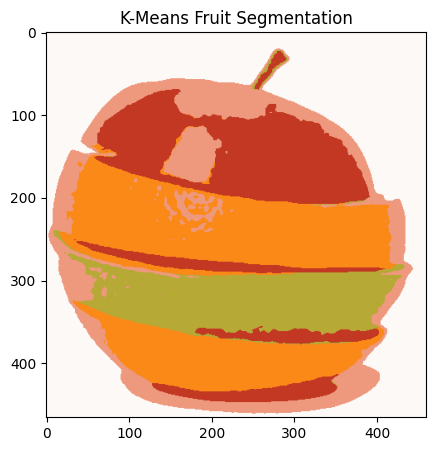

In [59]:
plt.figure(figsize=(6, 5))
plt.imshow(segmented)
plt.title("K-Means Fruit Segmentation")


In [53]:
gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(
    gray, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
kernel = np.ones((5, 5), np.uint8)

In [54]:
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
fruits = cv2.bitwise_and(rgb, rgb, mask=mask)

Text(0.5, 1.0, 'Final Fruit Segmentation')

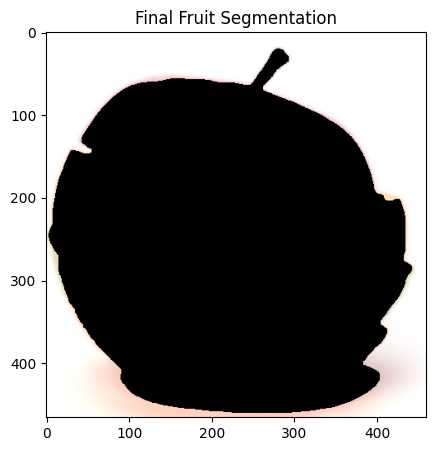

In [58]:
plt.figure(figsize=(6, 5))
plt.imshow(fruits)
plt.title("Final Fruit Segmentation")
